# Week 2 — Statistical Anomaly Detection

**Goal:** Flag anomalous demand days per product category with the **Z-Score** method.

> We detect on the **residual** (demand minus trend & weekly seasonality) so that
> normal seasonal peaks are not mistaken for anomalies. `Clothing` is largely
> interpolated, so treat its flags with caution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DAILY_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'

NUM_COLS = ['units_sold', 'inventory_level', 'unit_price', 'warehouse_dispatch_rate']
TARGET = 'units_sold'

daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)
print('Loaded shape:', daily.shape)
print('Categories:', sorted(daily['product_category'].unique()))
daily.head()

Loaded shape: (13057, 7)
Categories: ['Apparel', 'Automotive Parts', 'Beauty', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Office Supplies', 'Pet Supplies', 'Sporting Goods', 'Toys']


,date,product_category,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag
0,2020-01-01,Apparel,453.9,719.0,168.09,426.4,False
1,2020-01-02,Apparel,445.1,716.9,171.46,69.9,False
2,2020-01-03,Apparel,483.4,711.2,167.15,463.2,False
3,2020-01-04,Apparel,600.6,712.1,172.11,557.1,True
4,2020-01-05,Apparel,407.2,1216.3,171.24,422.8,False


## 1. Deseasonalize: compute the residual per category

Decompose each category's `units_sold` (additive, weekly period) and keep the
**residual** = demand with trend and weekly seasonality removed. Anomalies are the
residual values that stand out from the rest.

In [2]:
def add_residual(frame):
    """Add a 'residual' column (units_sold minus trend & weekly seasonality) per category."""
    parts = []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.sort_values('date').copy()
        result = seasonal_decompose(sub.set_index('date')[TARGET], model='additive', period=7)
        sub['residual'] = result.resid.values
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)

work = add_residual(daily)
print('Rows with a residual value:', int(work['residual'].notna().sum()), 'of', len(work))
work[['date', 'product_category', 'units_sold', 'residual']].head()

Rows with a residual value: 12991 of 13057


,date,product_category,units_sold,residual
0,2020-01-01,Apparel,453.9,NaN
1,2020-01-02,Apparel,445.1,NaN
2,2020-01-03,Apparel,483.4,NaN
3,2020-01-04,Apparel,600.6,125.143710
4,2020-01-05,Apparel,407.2,-46.178107


## 2. Z-Score method

Within each category, standardize the residual and flag any day whose absolute
z-score exceeds **3** (roughly beyond 3 standard deviations).

In [3]:
Z_THRESH = 3.0

def zscore(s):
    std = s.std(ddof=0)
    return (s - s.mean()) / std if std else s * 0

work['z'] = work.groupby('product_category')['residual'].transform(zscore)
work['anomaly_z'] = work['z'].abs() > Z_THRESH
print('Z-Score anomalies:', int(work['anomaly_z'].sum()))
work.loc[work['anomaly_z'], ['date', 'product_category', 'units_sold', 'residual', 'z']].head()

Z-Score anomalies: 275


,date,product_category,units_sold,residual,z
23,2020-01-24,Apparel,642.8,160.858178,3.788634
46,2020-02-16,Apparel,632.5,186.236178,4.386577
77,2020-03-18,Apparel,642.8,182.292552,4.293659
127,2020-05-07,Apparel,642.8,192.530347,4.534876
147,2020-05-27,Apparel,572.3,141.363981,3.329323


## 3. Per-category summary & visualization

Count Z-Score anomalies per category, then plot one category's demand with its
flagged days marked so the results can be sanity-checked visually.

In [4]:
summary = (work.groupby('product_category')['anomaly_z'].sum().astype(int)
               .to_frame('z_anomalies'))
summary['days'] = work.groupby('product_category').size()
print('Total Z-Score anomalies:', int(work['anomaly_z'].sum()))
summary

Total Z-Score anomalies: 275


,z_anomalies,days
product_category,,
Apparel,28,1187
Automotive Parts,23,1187
Beauty,30,1187
Clothing,31,1187
Electronics,18,1187
Furniture,24,1187
Groceries,24,1187
Office Supplies,32,1187
Pet Supplies,23,1187


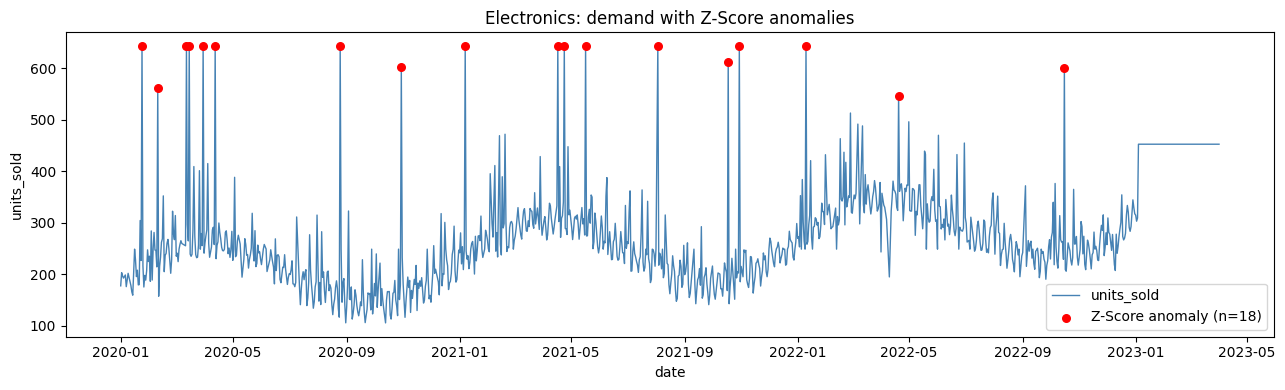

In [5]:
SAMPLE_CAT = 'Electronics'
sub = work[work['product_category'] == SAMPLE_CAT].sort_values('date')
hits = sub[sub['anomaly_z']]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sub['date'], sub['units_sold'], color='steelblue', lw=1, label='units_sold')
ax.scatter(hits['date'], hits['units_sold'], color='red', s=30, zorder=5,
           label=f'Z-Score anomaly (n={len(hits)})')
ax.set_title(f'{SAMPLE_CAT}: demand with Z-Score anomalies')
ax.set_xlabel('date'); ax.set_ylabel('units_sold'); ax.legend()
plt.tight_layout(); plt.show()